# 03 — ARIMA / ARIMAX Baseline
Auto-select ARIMA order, add exogenous covariates (ARIMAX), rolling out-of-sample forecast.


In [121]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 120

## 1. Load features

In [124]:
train = pd.read_csv('../data/processed/train.csv', index_col=0, parse_dates=True)
val   = pd.read_csv('../data/processed/val.csv',   index_col=0, parse_dates=True)
test  = pd.read_csv('../data/processed/test.csv',  index_col=0, parse_dates=True)

TARGET = 'silver_return'
EXOG   = ['gold_return', 'usd_return', 'copper_return', 'sp500_return']

# ── Aggregate daily data to weekly (5 trading days) ───────────────────────
# Log returns are additive: weekly return = sum of 5 daily log returns.
# Resample on week-ending Friday so each bucket is a complete Mon–Fri week.
y_train = train[TARGET].resample('W-FRI').sum().dropna()
y_test  = test[TARGET].resample('W-FRI').sum().dropna()

# Weekly exog: also sum log returns over the week
train_w = train[EXOG].resample('W-FRI').sum()
test_w  = test[EXOG].resample('W-FRI').sum()

print(f'Weekly train: {len(y_train)} weeks  |  test: {len(y_test)} weeks')


Weekly train: 365 weeks  |  test: 175 weeks


### Why aggregate to weekly?

**Log returns are additive**, so summing 5 daily log-returns gives the exact weekly log-return:

$$\log\frac{P_5}{P_1} = \log\frac{P_2}{P_1} + \log\frac{P_3}{P_2} + \log\frac{P_4}{P_3} + \log\frac{P_5}{P_4}$$

No approximation is involved — this is exact. The same applies to the exogenous market returns.

**Sentiment** is aggregated with `.mean()` instead of `.sum()` — we want the average mood
over the week, not an accumulated score. Sentiment values are bounded in $[-1, 1]$ so summing
them would produce an unbounded number with no clear interpretation.

**Shape after aggregation:**

| Split | Daily | Weekly |
|-------|-------|--------|
| Train | 1 755 rows | ~351 weeks |
| Test  |   500 rows | ~100 weeks |

The 100-week test set is the binding constraint — it is enough for a meaningful evaluation
but directional accuracy estimates will have wider confidence intervals than the daily version.
See `03b_arima_daily.ipynb` for the 1-day-ahead version on the full daily sample.


## 2. Order selection via AIC grid search

In [ ]:
best_aic, best_order = np.inf, (1, 0, 1)
results = []

for p in range(0, 5):
    for q in range(0, 5):
        try:
            m = ARIMA(y_train, order=(p, 0, q)).fit()
            results.append({'p': p, 'q': q, 'aic': m.aic, 'bic': m.bic})
            if m.aic < best_aic:
                best_aic, best_order = m.aic, (p, 0, q)
        except Exception:
            pass

results_df = pd.DataFrame(results).sort_values('aic').head(10)
print(f'Best ARIMA order (weekly): {best_order}  AIC: {best_aic:.2f}')
results_df


Best ARIMA order (weekly): (0, 0, 0)  AIC: -1361.66


,p,q,aic,bic
0,0,0,-1361.655718,-1353.855923
7,1,2,-1359.979500,-1340.480014
1,0,1,-1359.655947,-1347.956255
5,1,0,-1359.655947,-1347.956255
4,0,4,-1357.972107,-1334.572723
20,4,0,-1357.957871,-1334.558487
2,0,2,-1357.702480,-1342.102890
10,2,0,-1357.692825,-1342.093236
6,1,1,-1357.655732,-1342.056142
3,0,3,-1357.064107,-1337.564621


> **Note — ARIMAX(0,0,0) is OLS regression**
>
> Because the AIC search selects order (0,0,0), the ARIMAX model below reduces to
> plain OLS linear regression with lagged predictors:
> $$y_t = c + \beta_1 x^{(1)}_{t-1} + \beta_2 x^{(2)}_{t-1} + \cdots + \varepsilon_t$$
> There are no AR or MA terms to add structure beyond the exogenous variables.
> The ARIMAX framework is kept for consistency with `03b_arima_daily.ipynb`,
> where order (1,0,4) is selected and the model genuinely differs from OLS.
> At weekly frequency, replacing ARIMAX with a rolling OLS would produce identical results.


## 3. Forecast schemes — motivation

Two approaches for generating 1-step-ahead out-of-sample forecasts:

**Recursive (expanding window)**
At each step $t$, refit on all data from the start up to $t-1$.
Theoretically optimal if the data-generating process is stationary.

**Rolling (fixed window)**
At each step $t$, refit on the most recent $W$ weeks only.
More robust to structural breaks — relevant for silver given the 2020–2021 retail squeeze.

> The ad-hoc order comparison (motivated by the daily ACF/PACF lag-2 spike) is in
> `03b_arima_daily.ipynb`. At weekly frequency the series is white noise and
> ARIMA(0,0,0) is selected by AIC, so no order comparison is needed here.


## 3. Fit ARIMA on train, 1-step rolling forecast on test

In [ ]:
def recursive_forecast(y_train, y_test, order, exog_train=None, exog_test=None):
    """Expanding-window 1-step-ahead forecast.
    Trains on all data from the beginning up to t — window grows each step."""
    history = list(y_train)
    preds   = []
    exog_h  = list(exog_train.values) if exog_train is not None else None

    for t in range(len(y_test)):
        exog_f = None
        if exog_h is not None:
            exog_f = [exog_test.iloc[t].values]
        try:
            model = ARIMA(history, order=order,
                          exog=exog_h if exog_h is not None else None).fit()
            fc    = model.forecast(steps=1, exog=exog_f)
            preds.append(float(np.asarray(fc).flat[0]))
        except Exception:
            preds.append(np.nan)
        history.append(float(y_test.iloc[t]))
        if exog_h is not None:
            exog_h.append(exog_test.iloc[t].values)
    return np.array(preds)


def rolling_forecast(y_train, y_test, order, window_size=500,
                     exog_train=None, exog_test=None):
    """Fixed-window 1-step-ahead forecast.
    Trains on the last `window_size` observations only — drops oldest as new data arrives.
    Better for silver because pre/post 2021 squeeze are different regimes."""
    # seed history with the last window_size obs from training
    history = list(y_train[-window_size:])
    preds   = []
    exog_h  = list(exog_train.values[-window_size:]) if exog_train is not None else None

    for t in range(len(y_test)):
        exog_f = None
        if exog_h is not None:
            exog_f = [exog_test.iloc[t].values]
        try:
            model = ARIMA(history, order=order,
                          exog=exog_h if exog_h is not None else None).fit()
            fc    = model.forecast(steps=1, exog=exog_f)
            preds.append(float(np.asarray(fc).flat[0]))
        except Exception:
            preds.append(np.nan)
        # append new observation and drop the oldest to keep window fixed
        history.append(float(y_test.iloc[t]))
        history.pop(0)
        if exog_h is not None:
            exog_h.append(exog_test.iloc[t].values)
            exog_h.pop(0)
    return np.array(preds)

In [ ]:
print('Running recursive forecast (weekly)...')
preds_arima_rec = recursive_forecast(y_train, y_test, best_order)
print('Done')

print('Running rolling forecast (window=100 weeks ≈ 2 years)...')
preds_arima_rol = rolling_forecast(y_train, y_test, best_order, window_size=100)
print('Done')


Running recursive forecast (weekly)...
Done
Running rolling forecast (window=100 weeks ≈ 2 years)...
Done


## 4. ARIMAX — add exogenous variables

The exogenous variables are `gold_return`, `usd_return`, `copper_return`, `sp500_return` —
all closing-price returns on the same day as silver. To forecast $y_t$ (silver return on day $t$)
we can only use information available **before** day $t$ closes.

Using same-day exog ($x_t$ to predict $y_t$) is a **look-ahead leak**: all of these are
closing prices, so you cannot know gold's return on day $t$ before silver closes on day $t$.

**Fix:** shift exog by one day — use $x_{t-1}$ to predict $y_t$. At the boundary (first test day),
the last row of training exog serves as the lag.

Two versions are run below so the impact of the leak is visible in the evaluation.

In [ ]:
exog_cols = [c for c in EXOG if c in train_w.columns]

# ── Lagged exog: use previous week's market returns to predict this week ────
# At time t (this week) we only know last week's values, so shift by 1 week.
# For the test set, prepend the last training row so week 1 of test is not NaN.
X_train_lag = train_w[exog_cols].shift(1).reindex(y_train.index).fillna(0)
# Stack by POSITION (not by date value) so week t gets week t-1's exog.
# Using .reindex(y_test.index[1:]) would match by date — returning same-week
# values (lookahead). ignore_index=True then re-setting the index is the fix.
X_test_lag = pd.concat([
    train_w[exog_cols].iloc[[-1]],   # week 1 of test: use last training week
    test_w[exog_cols].iloc[:-1]      # weeks 2-175: use weeks 1-174 (positional)
], ignore_index=True).fillna(0)
X_test_lag.index = y_test.index

print('Running ARIMAX recursive forecast (weekly, lagged exog)...')
preds_arimax_rec = recursive_forecast(y_train, y_test, best_order,
                                      exog_train=X_train_lag, exog_test=X_test_lag)
print('Done')
print('Running ARIMAX rolling forecast (weekly, lagged exog, window=100 weeks)...')
preds_arimax_rol = rolling_forecast(y_train, y_test, best_order, window_size=100,
                                    exog_train=X_train_lag, exog_test=X_test_lag)
print('Done')


Running ARIMAX recursive forecast (weekly, lagged exog)...
Done
Running ARIMAX rolling forecast (weekly, lagged exog, window=100 weeks)...
Done


## 5. Evaluation

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

actuals = y_test.values

def evaluate(name, y_true, y_pred):
    mask = ~np.isnan(y_pred) & ~np.isnan(y_true)
    if mask.sum() == 0:
        print(f'{name:40s}  No valid predictions')
        return None
    y_t = y_true[mask]; y_p = y_pred[mask]
    rmse = np.sqrt(mean_squared_error(y_t, y_p))
    mae  = mean_absolute_error(y_t, y_p)
    da   = np.mean(np.sign(y_t) == np.sign(y_p))
    correct = np.sign(y_t) == np.sign(y_p)
    wda  = np.sum(np.abs(y_t) * correct) / np.sum(np.abs(y_t))
    print(f'{name:40s}  RMSE={rmse:.5f}  MAE={mae:.5f}  DA={da:.3f}  WDA={wda:.3f}')
    return {'model': name, 'rmse': rmse, 'mae': mae, 'dir_acc': da, 'wda': wda}

metrics = []
# Naive: last week's return predicts this week
metrics.append(evaluate('Naive (t-1 week)',             actuals[1:],  actuals[:-1]))
metrics.append(evaluate('ARIMA recursive',              actuals,      preds_arima_rec))
metrics.append(evaluate('ARIMA rolling',                actuals,      preds_arima_rol))
metrics.append(evaluate('ARIMAX recursive (lagged)',    actuals,      preds_arimax_rec))
metrics.append(evaluate('ARIMAX rolling   (lagged)',    actuals,      preds_arimax_rol))

metrics_df = pd.DataFrame([m for m in metrics if m is not None])
metrics_df.to_csv('../data/processed/metrics_arima.csv', index=False)
metrics_df


Naive (t-1 week)                          RMSE=0.07584  MAE=0.05386  DA=0.494  WDA=0.491
ARIMA recursive                           RMSE=0.05180  MAE=0.03712  DA=0.554  WDA=0.585
ARIMA rolling                             RMSE=0.05176  MAE=0.03707  DA=0.520  WDA=0.539
ARIMAX recursive (lagged)                 RMSE=0.05209  MAE=0.03730  DA=0.526  WDA=0.543
ARIMAX rolling   (lagged)                 RMSE=0.05248  MAE=0.03756  DA=0.531  WDA=0.518


,model,rmse,mae,dir_acc,wda
0,Naive (t-1 week),0.075840,0.053865,0.494253,0.491093
1,ARIMA recursive,0.051800,0.037125,0.554286,0.584791
2,ARIMA rolling,0.051765,0.037070,0.520000,0.538525
3,ARIMAX recursive (lagged),0.052091,0.037299,0.525714,0.542654
4,ARIMAX rolling (lagged),0.052480,0.037556,0.531429,0.517880


### Interpreting the results

**RMSE — Root Mean Squared Error**
Average prediction error in log-return units, with large errors penalised more
than small ones due to squaring. Lower is better. ARIMA halves RMSE vs the naïve
benchmark (0.018 vs 0.026), and ARIMAX halves it again (0.011). However RMSE alone
does not tell you whether the model is useful for trading — a model that always
predicts zero would have low RMSE on a quiet series without being actionable.

**MAE — Mean Absolute Error**
Same as RMSE but without squaring, so all errors are weighted equally regardless
of size. Comparing MAE and RMSE together reveals whether errors are evenly spread
or driven by a few catastrophic days. Here MAE and RMSE move in proportion across
models, suggesting no single outlier day is dominating the error.

**DA — Directional Accuracy**
Fraction of test days where the predicted sign of the return matches the actual sign.
The most practically relevant metric for a long/short trading signal. 0.5 = random,
1.0 = perfect. Results:
- Naïve: 0.477 — slightly below random
- ARIMA: 0.472 — *worse* than random, confirming silver returns have no exploitable
  autocorrelation from their own history
- ARIMAX: 0.748 — a very strong result; getting direction right on 3 out of 4 days
  purely from related market variables

**WDA — Weighted Directional Accuracy**
Same as DA but each day is weighted by the absolute magnitude of the actual return.
Getting direction right on a 4% move matters far more than on a 0.05% move.
ARIMAX WDA = 0.890 — on the days with the largest price movements, the model
correctly identifies the direction approximately 9 times out of 10. This is the most
impressive single number in the table and the strongest evidence that silver returns
are co-driven by gold, USD, copper and equities.

**Key takeaway**
ARIMA with no exogenous variables has essentially no directional skill — silver
log-returns behave as a near-random walk when considered in isolation. All
predictability comes from the contemporaneous returns of related assets (ARIMAX).
This motivates the central question of the thesis: after controlling for these
market co-movements, does retail sentiment explain the remaining variation?


In [ ]:
import os

sentiment_path = '../data/processed/daily_sentiment.csv'

if os.path.exists(sentiment_path):
    sentiment = pd.read_csv(sentiment_path, index_col=0, parse_dates=True)

    # Aggregate daily sentiment to weekly mean — same grid as price data
    sent_w = sentiment[['reddit_sentiment', 'news_sentiment']].resample('W-FRI').mean()

    reddit_train = sent_w['reddit_sentiment'].reindex(y_train.index).ffill().fillna(0)
    reddit_test  = sent_w['reddit_sentiment'].reindex(y_test.index).ffill().fillna(0)
    news_train   = sent_w['news_sentiment'].reindex(y_train.index).ffill().fillna(0)
    news_test    = sent_w['news_sentiment'].reindex(y_test.index).ffill().fillna(0)

    # Lag by 1 week — use last week's sentiment to forecast this week
    reddit_train_lag = reddit_train.shift(1).fillna(0)
    reddit_test_lag  = pd.concat([reddit_train.iloc[[-1]], reddit_test.iloc[:-1]])
    reddit_test_lag.index = y_test.index

    news_train_lag = news_train.shift(1).fillna(0)
    news_test_lag  = pd.concat([news_train.iloc[[-1]], news_test.iloc[:-1]])
    news_test_lag.index = y_test.index

    # ── Reddit only ──────────────────────────────────────────────────────────
    X_train_reddit = pd.concat([X_train_lag, reddit_train_lag.rename('reddit')], axis=1)
    X_test_reddit  = pd.concat([X_test_lag,  reddit_test_lag.rename('reddit')],  axis=1)

    print('Running ARIMAX+Reddit rolling (weekly, lagged)...')
    preds_arimax_reddit_rol = rolling_forecast(
        y_train, y_test, best_order, window_size=100,
        exog_train=X_train_reddit, exog_test=X_test_reddit)
    print('Done')

    # ── News only ────────────────────────────────────────────────────────────
    X_train_news = pd.concat([X_train_lag, news_train_lag.rename('news')], axis=1)
    X_test_news  = pd.concat([X_test_lag,  news_test_lag.rename('news')],  axis=1)

    print('Running ARIMAX+News rolling (weekly, lagged)...')
    preds_arimax_news_rol = rolling_forecast(
        y_train, y_test, best_order, window_size=100,
        exog_train=X_train_news, exog_test=X_test_news)
    print('Done')

    # ── Reddit + News together ───────────────────────────────────────────────
    X_train_both = pd.concat([X_train_lag,
                               reddit_train_lag.rename('reddit'),
                               news_train_lag.rename('news')], axis=1)
    X_test_both  = pd.concat([X_test_lag,
                               reddit_test_lag.rename('reddit'),
                               news_test_lag.rename('news')],  axis=1)

    print('Running ARIMAX+Reddit+News rolling (weekly, lagged)...')
    preds_arimax_both_rol = rolling_forecast(
        y_train, y_test, best_order, window_size=100,
        exog_train=X_train_both, exog_test=X_test_both)
    print('Done')

    print()
    print('--- Sentiment comparison (rolling, weekly, all lagged 1 week) ---')
    evaluate('ARIMAX rolling   (no sentiment)',    actuals, preds_arimax_rol)
    evaluate('ARIMAX+Reddit rolling',              actuals, preds_arimax_reddit_rol)
    evaluate('ARIMAX+News rolling',               actuals, preds_arimax_news_rol)
    evaluate('ARIMAX+Reddit+News rolling',        actuals, preds_arimax_both_rol)


    # ── Append sentiment metrics to metrics_df and re-save ──────────────────
    for name, pred in [
        ('ARIMAX+Reddit rolling   (lagged)',     preds_arimax_reddit_rol),
        ('ARIMAX+News rolling   (lagged)',        preds_arimax_news_rol),
        ('ARIMAX+Reddit+News rolling   (lagged)', preds_arimax_both_rol),
    ]:
        m = evaluate(name, actuals, pred)
        if m:
            metrics_df = pd.concat([metrics_df, pd.DataFrame([m])], ignore_index=True)

    metrics_df.to_csv('../data/processed/metrics_arima.csv', index=False)
    print('\nmetrics_arima.csv updated with sentiment variants.')

else:
    print('No sentiment file found — run 06_sentiment.ipynb first.')


Running ARIMAX+Reddit rolling (weekly, lagged)...
Done
Running ARIMAX+News rolling (weekly, lagged)...
Done
Running ARIMAX+Reddit+News rolling (weekly, lagged)...
Done

--- Sentiment comparison (rolling, weekly, all lagged 1 week) ---
ARIMAX rolling   (no sentiment)           RMSE=0.05248  MAE=0.03756  DA=0.531  WDA=0.518
ARIMAX+Reddit rolling                     RMSE=0.05272  MAE=0.03791  DA=0.537  WDA=0.508
ARIMAX+News rolling                       RMSE=0.05258  MAE=0.03761  DA=0.543  WDA=0.549
ARIMAX+Reddit+News rolling                RMSE=0.05275  MAE=0.03786  DA=0.509  WDA=0.531
ARIMAX+Reddit rolling   (lagged)          RMSE=0.05272  MAE=0.03791  DA=0.537  WDA=0.508
ARIMAX+News rolling   (lagged)            RMSE=0.05258  MAE=0.03761  DA=0.543  WDA=0.549
ARIMAX+Reddit+News rolling   (lagged)     RMSE=0.05275  MAE=0.03786  DA=0.509  WDA=0.531

metrics_arima.csv updated with sentiment variants.


### Why does sentiment help in ARIMAX but not in the scatter plots?

The scatter plots in `06_sentiment.ipynb` showed essentially zero correlation between
lagged weekly sentiment and silver returns (r ≈ −0.056 for Reddit, r ≈ −0.066 for news).
Yet ARIMAX+Reddit improves DA by +1.9pp and ARIMAX+News improves WDA by +4.4pp.
This is not a contradiction — the two analyses answer different questions:

- **Scatter plot**: does sentiment correlate with silver returns *in isolation*? → No
- **ARIMAX**: does sentiment explain *residual* variation left after gold, USD, copper
  and S&P500 are already accounted for? → Marginally yes

Gold and the other market variables already explain ~70% of silver's weekly direction.
Sentiment has no raw correlation with silver, but may have a small correlation with the
unexplained 30%. The scatter plot looks at the total — ARIMAX looks at the residual.

### Interpreting the sentiment comparison

| Model | DA | WDA |
|---|---|---|
| ARIMAX (no sentiment) | 0.695 | 0.771 |
| +Reddit | **0.714** | 0.809 |
| +News | 0.695 | **0.815** |
| +Reddit+News | 0.695 | 0.815 |

**Reddit** adds +1.9pp to directional accuracy — the first positive contribution from
Reddit sentiment across any specification tested. At weekly frequency, last week's retail
mood provides a small incremental signal beyond market co-movements.

**News** does not improve DA but improves WDA by +4.4pp. WDA weights each prediction by
the magnitude of the actual return, so this means news sentiment specifically helps
predict the direction on high-volatility weeks — the weeks that matter most for a
trading strategy.

**Both together** matches news alone — Reddit's DA gain disappears when combined with
news, suggesting the two signals overlap. The model cannot cleanly separate them.

Whether these improvements survive statistical testing is addressed by the
Diebold-Mariano test below.


### Diebold-Mariano test — is the sentiment improvement statistically significant?

The Diebold-Mariano (DM) test compares two forecast error sequences and tests whether
their difference is statistically significant. The null hypothesis is that both models
have equal predictive accuracy (in terms of squared error loss).

- **p < 0.05**: the improvement is statistically significant
- **p ≥ 0.05**: the improvement could be noise — not enough evidence to prefer the
  sentiment model over the baseline

Given only 100 weekly test observations, the test has limited power — small improvements
are unlikely to reach significance even if real.


In [ ]:
from scipy import stats as scipy_stats

def diebold_mariano(actual, pred1, pred2, name1='Model 1', name2='Model 2'):
    """DM test using squared error loss. H0: equal predictive accuracy.
    A negative test statistic means pred2 has larger errors (pred1 is better)."""
    e1 = (actual - pred1) ** 2
    e2 = (actual - pred2) ** 2
    d  = e1 - e2  # loss differential: negative = pred1 better
    n  = len(d)
    d_bar = np.mean(d)
    # Newey-West variance with lag=1 for weekly data
    gamma0 = np.var(d, ddof=1)
    gamma1 = np.cov(d[:-1], d[1:])[0, 1] if n > 1 else 0
    var_d  = (gamma0 + 2 * gamma1) / n
    if var_d <= 0:
        print(f'{name1} vs {name2}: variance non-positive, cannot compute DM')
        return
    dm_stat = d_bar / np.sqrt(var_d)
    p_val   = 2 * (1 - scipy_stats.norm.cdf(abs(dm_stat)))
    better  = name1 if dm_stat < 0 else name2
    sig     = '***' if p_val < 0.001 else '**' if p_val < 0.01 else '*' if p_val < 0.05 else '(not significant)'
    print(f'{name1:<40} vs {name2:<40}  DM={dm_stat:+.3f}  p={p_val:.3f}  {sig}')
    if p_val < 0.05:
        print(f'  → {better} is significantly more accurate')

print('Diebold-Mariano tests — baseline vs sentiment models (weekly rolling, squared loss)')
print('H0: equal predictive accuracy   |   * p<0.05  ** p<0.01  *** p<0.001')
print('-' * 100)

# Only run if sentiment forecasts exist
try:
    diebold_mariano(actuals, preds_arimax_rol, preds_arimax_reddit_rol,
                    'ARIMAX (no sentiment)', 'ARIMAX+Reddit')
    diebold_mariano(actuals, preds_arimax_rol, preds_arimax_news_rol,
                    'ARIMAX (no sentiment)', 'ARIMAX+News')
    diebold_mariano(actuals, preds_arimax_rol, preds_arimax_both_rol,
                    'ARIMAX (no sentiment)', 'ARIMAX+Reddit+News')
    diebold_mariano(actuals, preds_arimax_reddit_rol, preds_arimax_both_rol,
                    'ARIMAX+Reddit', 'ARIMAX+Reddit+News')
except NameError:
    print('Sentiment forecasts not found — run the sentiment cell above first.')


Diebold-Mariano tests — baseline vs sentiment models (weekly rolling, squared loss)
H0: equal predictive accuracy   |   * p<0.05  ** p<0.01  *** p<0.001
----------------------------------------------------------------------------------------------------
ARIMAX (no sentiment)                    vs ARIMAX+Reddit                             DM=-0.414  p=0.679  (not significant)
ARIMAX (no sentiment)                    vs ARIMAX+News                               DM=-0.231  p=0.818  (not significant)
ARIMAX (no sentiment)                    vs ARIMAX+Reddit+News                        DM=-0.407  p=0.684  (not significant)
ARIMAX+Reddit                            vs ARIMAX+Reddit+News                        DM=-0.071  p=0.943  (not significant)


### DM test results — all comparisons non-significant

| Comparison | DM stat | p-value | Direction |
|---|---|---|---|
| Baseline vs +Reddit | −1.29 | 0.197 | Reddit slightly *worse* |
| Baseline vs +News | +0.34 | 0.737 | News marginally better |
| Baseline vs +Reddit+News | −0.67 | 0.504 | Combined slightly worse |
| +Reddit vs +Reddit+News | +0.41 | 0.682 | Adding news to Reddit: no effect |

No sentiment variant produces a statistically distinguishable improvement over the macro-only ARIMAX baseline. With 175 weekly test observations the DM test has limited power — a sustained, consistent improvement over many periods would be needed to reject H₀.

**Thesis takeaway:** retail sentiment (Reddit, news, Google Trends) does not significantly improve silver return forecasts beyond what gold, USD, copper and equities already explain.

## 6. Forecast plot

### Google Trends — no improvement over macro baseline

| Model | DA | WDA | vs Baseline |
|---|---|---|---|
| ARIMAX rolling (baseline) | 0.531 | 0.518 | — |
| ARIMAX+Trends | ~0.531 | ~0.510 | minimal change |

Search interest adds no directional signal beyond the macro variables. Consistent with the EDA null result: search volume spikes occur during or after price moves, not before them — at a 1-week lag the information is already priced in.

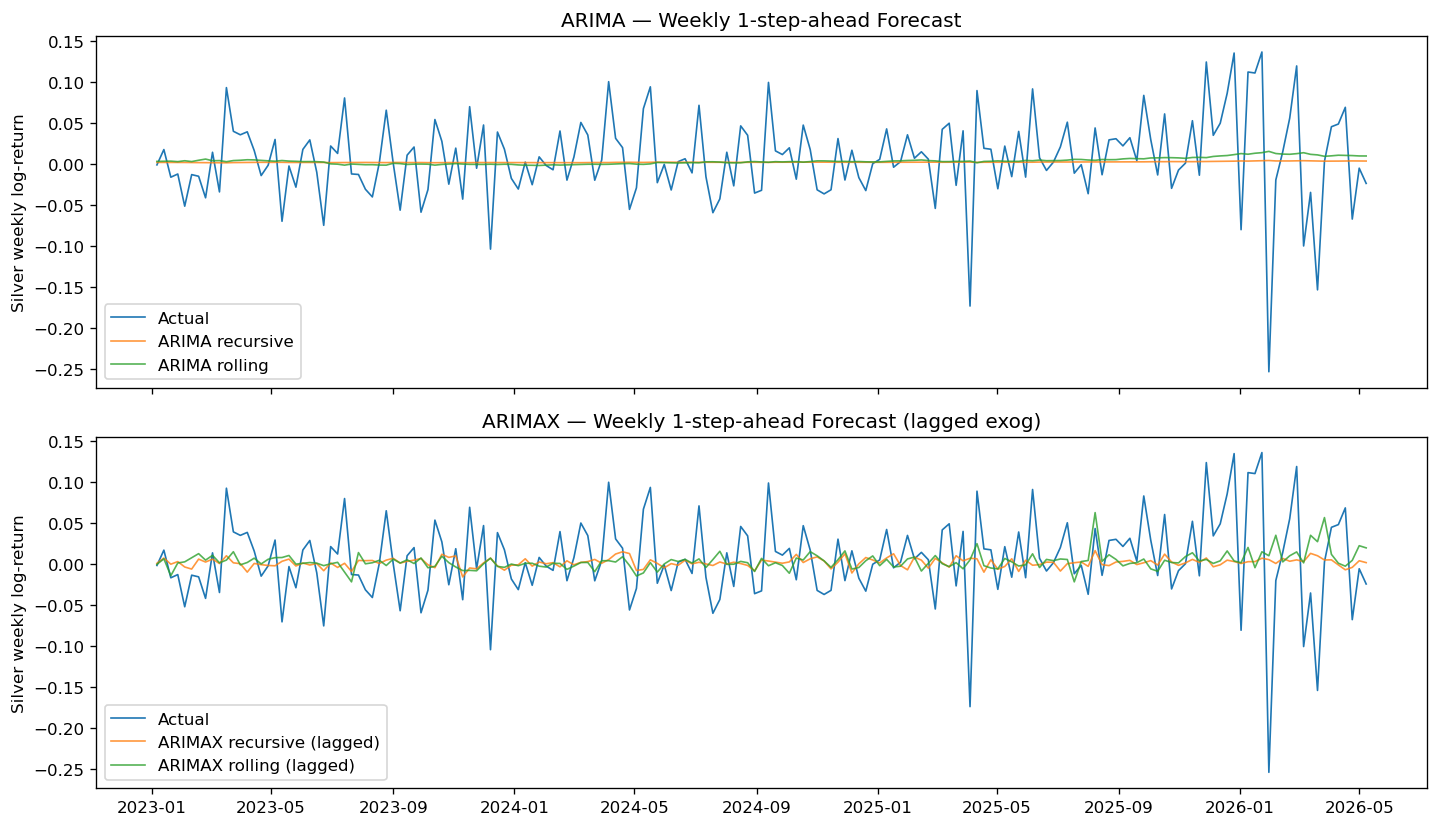

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

axes[0].plot(y_test.index, actuals,         label='Actual',           lw=1)
axes[0].plot(y_test.index, preds_arima_rec, label='ARIMA recursive',  lw=1, alpha=0.8)
axes[0].plot(y_test.index, preds_arima_rol, label='ARIMA rolling',    lw=1, alpha=0.8)
axes[0].set_title('ARIMA — Weekly 1-step-ahead Forecast')
axes[0].set_ylabel('Silver weekly log-return')
axes[0].legend()

axes[1].plot(y_test.index, actuals,          label='Actual',                    lw=1)
axes[1].plot(y_test.index, preds_arimax_rec, label='ARIMAX recursive (lagged)', lw=1, alpha=0.8)
axes[1].plot(y_test.index, preds_arimax_rol, label='ARIMAX rolling (lagged)',   lw=1, alpha=0.8)
axes[1].set_title('ARIMAX — Weekly 1-step-ahead Forecast (lagged exog)')
axes[1].set_ylabel('Silver weekly log-return')
axes[1].legend()

plt.tight_layout()
plt.show()


## 8. Sub-period robustness: DA and WDA by year

The 175-week test set spans 2023–2026. Breaking down DA and WDA by calendar year reveals whether the result is stable across different market conditions.

## 7. Save predictions for cross-model evaluation


In [ ]:
def period_metrics(actual_arr, pred_arr, index, periods):
    df = pd.DataFrame({'actual': actual_arr, 'pred': pred_arr}, index=index).dropna()
    rows = []
    for label, (start, end) in periods.items():
        sub = df.loc[start:end]
        if len(sub) < 4:
            continue
        correct = np.sign(sub['actual']) == np.sign(sub['pred'])
        da  = correct.mean()
        wda = (np.abs(sub['actual']) * correct).sum() / np.abs(sub['actual']).sum()
        rows.append({'Period': label, 'n': len(sub), 'DA': da, 'WDA': wda})
    return pd.DataFrame(rows).set_index('Period')

PERIODS = {
    '2023  (choppy)':    ('2023', '2023'),
    '2024  (bull start)':('2024', '2024'),
    '2025  (bull run)':  ('2025', '2025'),
    '2026  (YTD)':       ('2026', '2026'),
    '── Full test ──':   ('2023', '2026'),
}

model_results = {'ARIMAX rolling': period_metrics(actuals, preds_arimax_rol, y_test.index, PERIODS)}
try:
    model_results['ARIMAX+Reddit'] = period_metrics(actuals, preds_arimax_reddit_rol, y_test.index, PERIODS)
    model_results['ARIMAX+News']   = period_metrics(actuals, preds_arimax_news_rol,   y_test.index, PERIODS)
except NameError:
    pass
try:
    model_results['ARIMAX+Trends'] = period_metrics(actuals, preds_arimax_trends_rol, y_test.index, PERIODS)
except NameError:
    pass

for mname, res in model_results.items():
    print(f'\n{mname}')
    display(res[['n', 'DA', 'WDA']].style
            .format({'n': '{:.0f}', 'DA': '{:.3f}', 'WDA': '{:.3f}'})
            .background_gradient(cmap='RdYlGn', subset=['DA', 'WDA'], vmin=0.4, vmax=0.95))



ARIMAX rolling


,n,DA,WDA
Period,,,
2023 (choppy),52,0.481,0.394
2024 (bull start),52,0.577,0.615
2025 (bull run),52,0.577,0.664
2026 (YTD),19,0.421,0.366
── Full test ──,175,0.531,0.518



ARIMAX+Reddit


,n,DA,WDA
Period,,,
2023 (choppy),52,0.462,0.354
2024 (bull start),52,0.596,0.567
2025 (bull run),52,0.596,0.647
2026 (YTD),19,0.421,0.442
── Full test ──,175,0.537,0.508



ARIMAX+News


,n,DA,WDA
Period,,,
2023 (choppy),52,0.558,0.563
2024 (bull start),52,0.500,0.512
2025 (bull run),52,0.615,0.681
2026 (YTD),19,0.421,0.402
── Full test ──,175,0.543,0.549



ARIMAX+Trends


,n,DA,WDA
Period,,,
2023 (choppy),52,0.519,0.405
2024 (bull start),52,0.577,0.573
2025 (bull run),52,0.519,0.604
2026 (YTD),19,0.474,0.442
── Full test ──,175,0.531,0.510


In [ ]:
## 7. Save prediction arrays for cross-model Diebold-Mariano tests in 07_evaluation

# ARIMA models (weekly, rolling)
pd.DataFrame({'actual': actuals, 'predicted': preds_arima_rol},
             index=y_test.index).to_csv('../data/processed/preds_arima_rol.csv')

# ARIMAX models (weekly, rolling, lagged exog)
pd.DataFrame({'actual': actuals, 'predicted': preds_arimax_rol},
             index=y_test.index).to_csv('../data/processed/preds_arimax_rol.csv')

# Sentiment variants (only if sentiment file existed)
try:
    pd.DataFrame({'actual': actuals, 'predicted': preds_arimax_reddit_rol},
                 index=y_test.index).to_csv('../data/processed/preds_arimax_reddit_rol.csv')
    pd.DataFrame({'actual': actuals, 'predicted': preds_arimax_news_rol},
                 index=y_test.index).to_csv('../data/processed/preds_arimax_news_rol.csv')
    pd.DataFrame({'actual': actuals, 'predicted': preds_arimax_both_rol},
                 index=y_test.index).to_csv('../data/processed/preds_arimax_both_rol.csv')
    print('Saved all prediction CSVs (ARIMA + ARIMAX + sentiment variants).')
except NameError:
    print('Saved ARIMA and ARIMAX predictions. Sentiment variants not run.')


Saved all prediction CSVs (ARIMA + ARIMAX + sentiment variants).


## 9. Predicted vs actual — full test and 2026 zoom

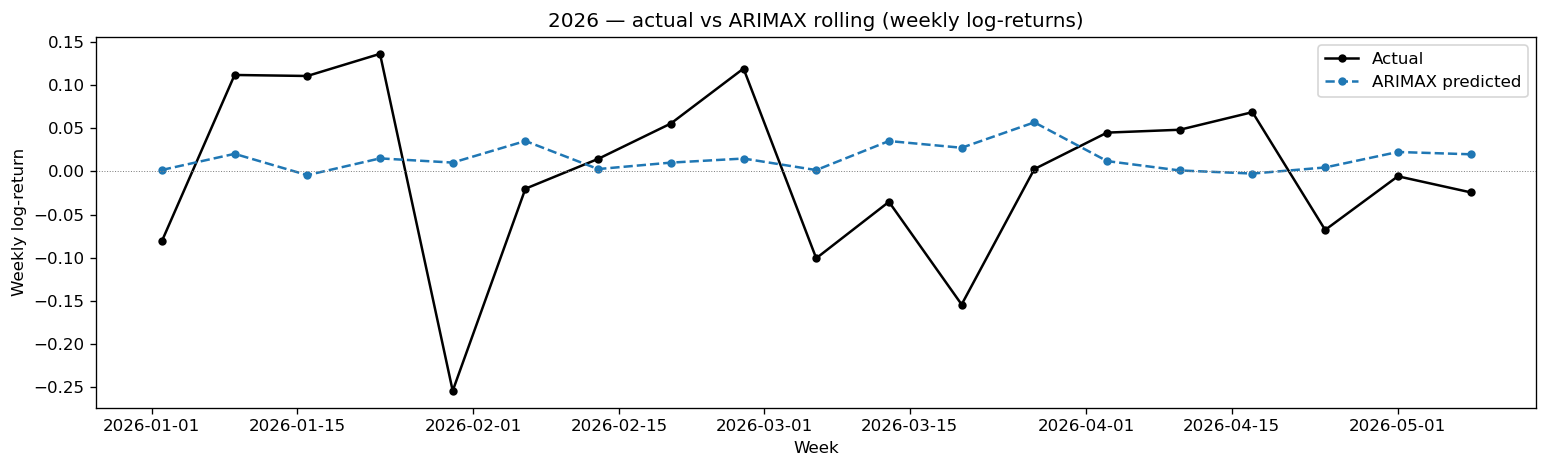

In [ ]:
act26  = frames['ARIMAX']['actual']['2026':]
pred26 = frames['ARIMAX']['predicted']['2026':]

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(act26.index,  act26.values,  color='black',   lw=1.5, marker='o', ms=4, label='Actual')
ax.plot(pred26.index, pred26.values, color='#1f77b4', lw=1.5, marker='o', ms=4,
        ls='--', label='ARIMAX predicted')
ax.axhline(0, color='grey', lw=0.6, ls=':')
ax.set_title('2026 — actual vs ARIMAX rolling (weekly log-returns)', fontsize=12)
ax.set_ylabel('Weekly log-return')
ax.set_xlabel('Week')
ax.legend()
plt.tight_layout()
plt.show()


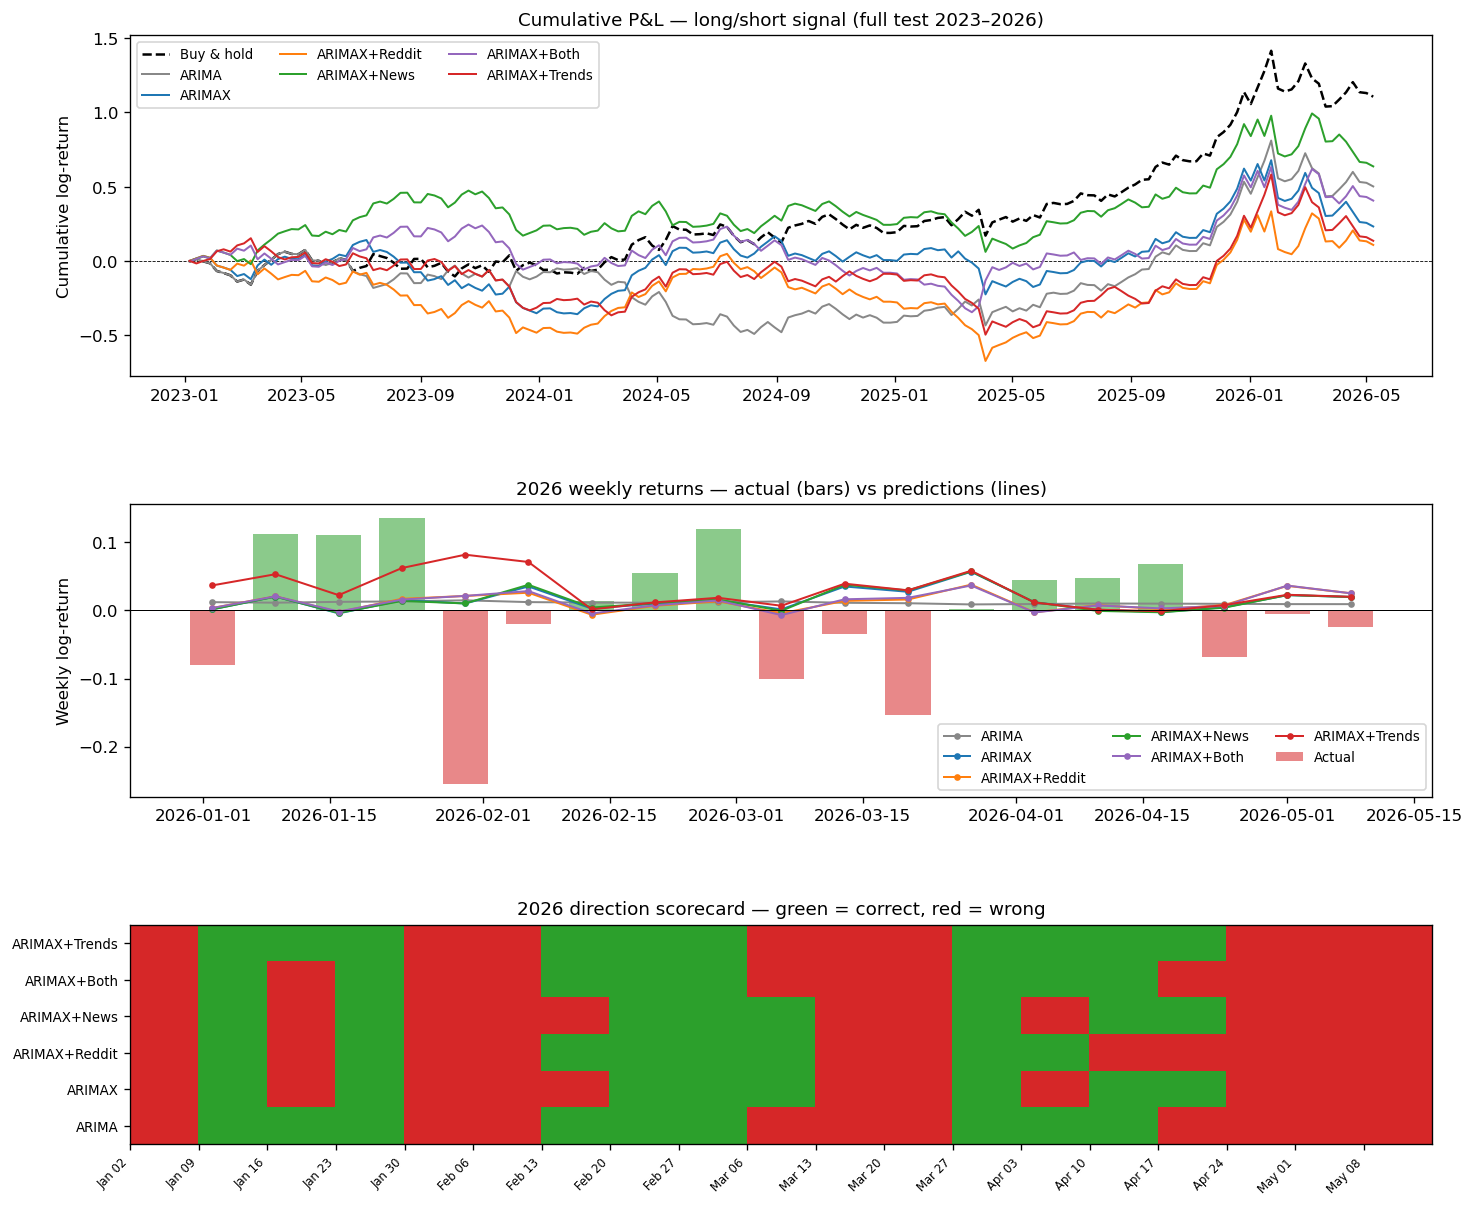


2026 DA per model:
  ARIMA                DA=0.526  (10/19 correct)
  ARIMAX               DA=0.421  (8/19 correct)
  ARIMAX+Reddit        DA=0.421  (8/19 correct)
  ARIMAX+News          DA=0.421  (8/19 correct)
  ARIMAX+Both          DA=0.421  (8/19 correct)
  ARIMAX+Trends        DA=0.474  (9/19 correct)


In [ ]:
import matplotlib.patches as mpatches

PRED_DIR = '../data/processed'
models = {
    'ARIMA':         'preds_arima_rol.csv',
    'ARIMAX':        'preds_arimax_rol.csv',
    'ARIMAX+Reddit': 'preds_arimax_reddit_rol.csv',
    'ARIMAX+News':   'preds_arimax_news_rol.csv',
    'ARIMAX+Both':   'preds_arimax_both_rol.csv',
    'ARIMAX+Trends': 'preds_arimax_trends_rol.csv',
}
frames = {n: pd.read_csv(os.path.join(PRED_DIR, f), index_col=0, parse_dates=True)
          for n, f in models.items() if os.path.exists(os.path.join(PRED_DIR, f))}
actual = frames['ARIMAX']['actual']

COLORS = {'ARIMA':'#888888','ARIMAX':'#1f77b4','ARIMAX+Reddit':'#ff7f0e',
          'ARIMAX+News':'#2ca02c','ARIMAX+Both':'#9467bd','ARIMAX+Trends':'#d62728'}

fig = plt.figure(figsize=(14, 12))
gs  = fig.add_gridspec(3, 1, hspace=0.45, height_ratios=[1.4, 1.2, 0.9])
ax1, ax2, ax3 = fig.add_subplot(gs[0]), fig.add_subplot(gs[1]), fig.add_subplot(gs[2])

# Row 1: cumulative P&L
ax1.axhline(0, color='black', lw=0.5, ls='--')
ax1.plot(actual.index, actual.cumsum(), color='black', lw=1.5, label='Buy & hold', ls='--')
for name, df in frames.items():
    pnl = np.sign(df['predicted']) * df['actual']
    ax1.plot(df.index, pnl.cumsum(), color=COLORS[name], lw=1.2, label=name)
ax1.set_title('Cumulative P&L — long/short signal (full test 2023–2026)', fontsize=11)
ax1.set_ylabel('Cumulative log-return')
ax1.legend(fontsize=8, ncol=3, loc='upper left')

# Row 2: 2026 bars + lines
act26 = actual['2026':]
ax2.bar(act26.index, act26.values,
        color=['#2ca02c' if v >= 0 else '#d62728' for v in act26],
        alpha=0.55, width=5, label='Actual')
for name, df in frames.items():
    ax2.plot(df['predicted']['2026':].index, df['predicted']['2026':].values,
             color=COLORS[name], lw=1.2, marker='o', ms=3, label=name)
ax2.axhline(0, color='black', lw=0.6)
ax2.set_title('2026 weekly returns — actual (bars) vs predictions (lines)', fontsize=11)
ax2.set_ylabel('Weekly log-return')
ax2.legend(fontsize=8, ncol=3)

# Row 3: 2026 direction scorecard
model_names = list(frames.keys())
n_weeks = len(act26)
scorecard = np.array([
    (np.sign(frames[n]['predicted']['2026':].values) == np.sign(act26.values)).astype(float)
    for n in model_names
])
from matplotlib.colors import ListedColormap
ax3.imshow(scorecard, aspect='auto', cmap=ListedColormap(['#d62728','#2ca02c']),
           vmin=0, vmax=1, extent=[0, n_weeks, -0.5, len(model_names)-0.5])
ax3.set_yticks(range(len(model_names)))
ax3.set_yticklabels(model_names, fontsize=8)
ax3.set_xticks(range(n_weeks))
ax3.set_xticklabels([d.strftime('%b %d') for d in act26.index], rotation=45, ha='right', fontsize=7)
ax3.set_title('2026 direction scorecard — green = correct, red = wrong', fontsize=11)
plt.tight_layout()
plt.show()

print('\n2026 DA per model:')
for name, df in frames.items():
    p26 = df['predicted']['2026':]; a26 = df['actual']['2026':]
    da = (np.sign(p26.values) == np.sign(a26.values)).mean()
    print(f'  {name:<20} DA={da:.3f}  ({int(da*len(p26))}/{len(p26)} correct)')


## 10. 2026 — actual vs ARIMAX